In [2]:
import cv2
import numpy as np
import imutils
from imutils import contours
import matplotlib.pyplot as plt

In [3]:
def show_image(title, img, cmap=None):
    plt.figure(figsize=(10, 8))
    if cmap is None and len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [4]:
image_path = '/Users/nitisj/Workspace/KMUTT/Image Processing/Final/sections/section_5.png'
roi = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

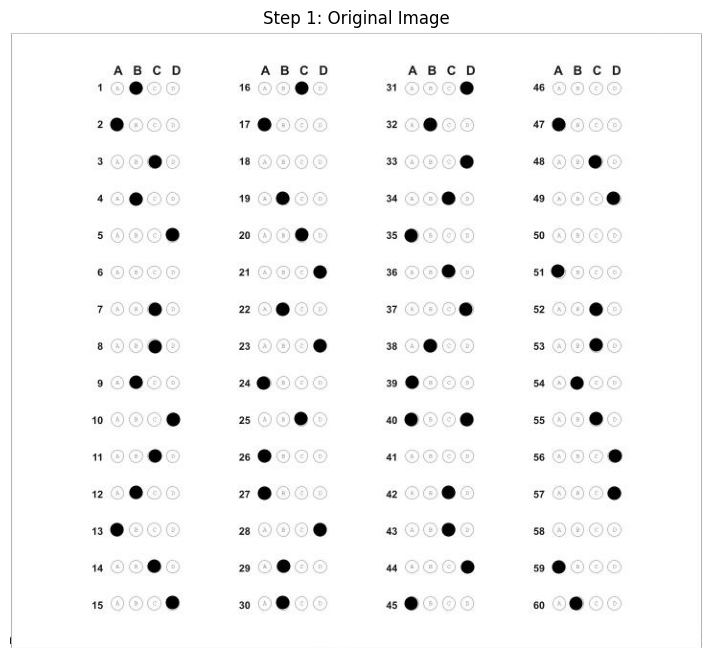

In [5]:
if roi is None:
    print(f"Error: Could not load {image_path}. Check the file name.")
    raise SystemExit

show_image("Step 1: Original Image", roi, cmap="gray")

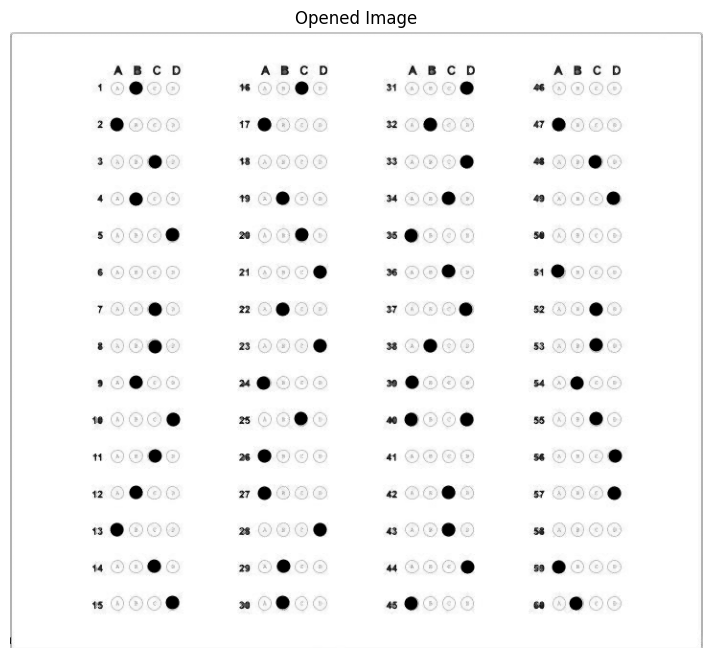

In [6]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3,3)
)

closed = cv2.morphologyEx(
    roi,
    cv2.MORPH_OPEN,
    kernel
)

show_image("Opened Image", closed, cmap="gray")

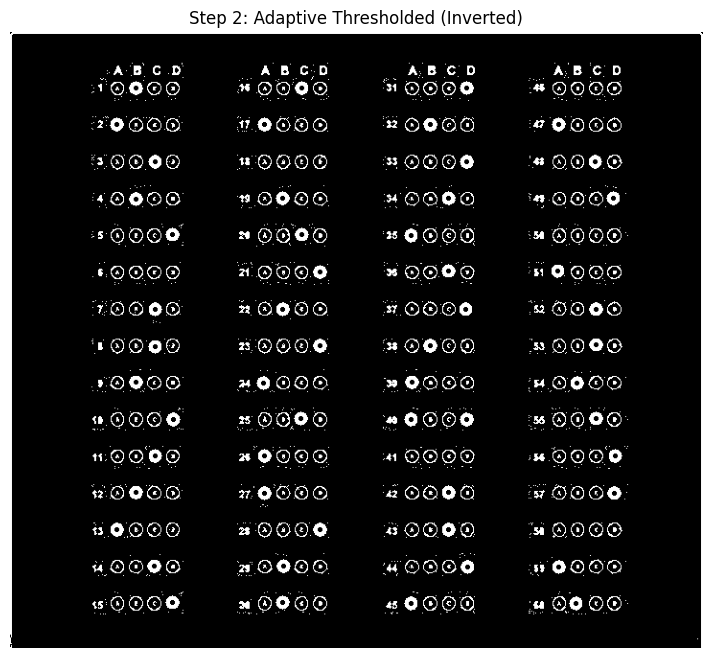

In [ ]:
# # Otsu's thresholding
# thresh = cv2.threshold(erode, 100, 200, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
# show_image("Step 4: Thresholded (Inverted)", thresh, cmap="gray")

# threshold using adaptive thresholding
thresh = cv2.adaptiveThreshold(closed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 5)
show_image("Step 2: Adaptive Thresholded (Inverted)", thresh, cmap="gray")

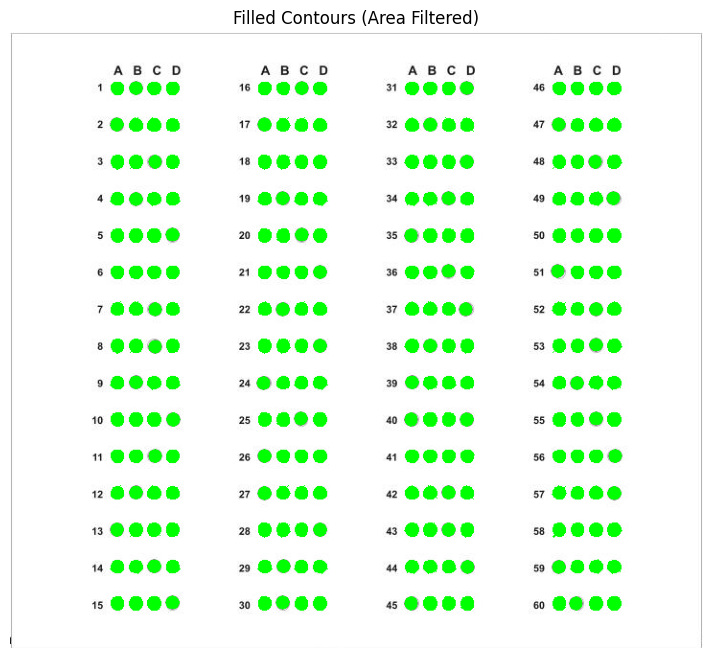

Total contours found: 1384
Contours after area filter: 240


In [8]:
cnts = cv2.findContours(
    thresh.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
cnts = imutils.grab_contours(cnts)

# Filter contours by area
min_area = 100
max_area = 1000
filtered_cnts = [c for c in cnts if min_area <= cv2.contourArea(c) <= max_area]

# Draw only filtered contours (filled)
output = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)
cv2.drawContours(output, filtered_cnts, -1, (0, 255, 0), -1)

show_image("Filled Contours (Area Filtered)", output)

print(f"Total contours found: {len(cnts)}")
print(f"Contours after area filter: {len(filtered_cnts)}")

Perfect! 240 bubbles found. Proceeding to label...


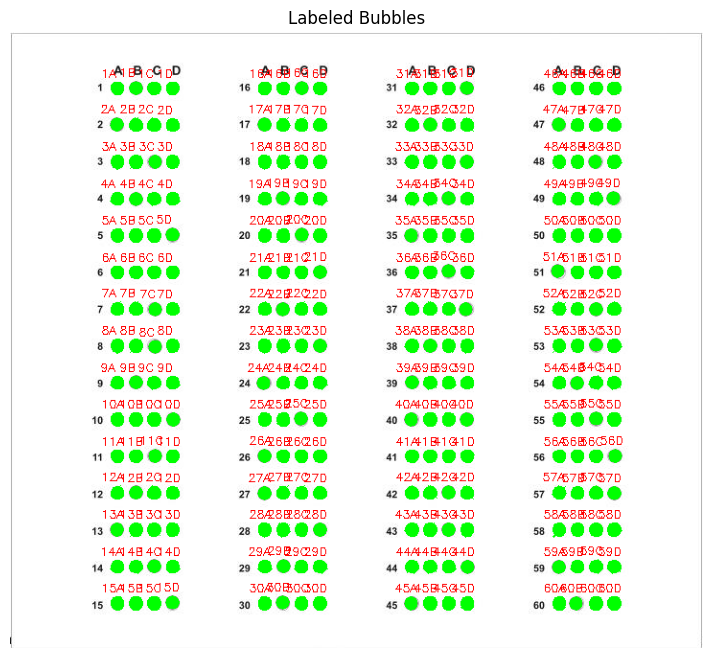

In [ ]:
# 1. Ensure you have exactly 240 bubbles before doing the math
if len(filtered_cnts) == 240:
    print("Perfect! 240 bubbles found. Proceeding to label...")
    
    # 2. Sort all 240 bubbles from top-to-bottom
    question_bubbles = contours.sort_contours(filtered_cnts, method="top-to-bottom")[0]
    
    option_letters = ['A', 'B', 'C', 'D']
    
    # 3. Loop over the bubbles in chunks of 16 (representing one horizontal row) (not always 16, but for this format it is)
    for row_idx, i in enumerate(range(0, len(question_bubbles), 16)):
        
        # Grab the 16 bubbles for this row and sort them left-to-right
        row_bubbles = contours.sort_contours(question_bubbles[i:i+16], method="left-to-right")[0]
        
        # 4. Split this row into 4 columns (the 4 blocks of questions)
        for block_idx in range(4):
            
            # MATH RULE: (Bros can change to suit other formats naja)
            # block_idx 0 = Q1-15 | block_idx 1 = Q16-30 | block_idx 2 = Q31-45 | block_idx 3 = Q46-60
            question_num = (block_idx * 15) + row_idx + 1
            
            # Extract the 4 bubbles (A, B, C, D) for this specific question
            start_bubble = block_idx * 4
            options = row_bubbles[start_bubble : start_bubble + 4]
            
            # 5. Label each bubble
            for opt_idx, bubble in enumerate(options):
                letter = option_letters[opt_idx]
                
                # Get coordinates to draw the label
                (x, y, w, h) = cv2.boundingRect(bubble)
                
                # Create the text label (e.g., "1A", "16C")
                label = f"{question_num}{letter}"
                
                # Draw the label directly onto image
                cv2.putText(output, label, (x - 10, y - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

    show_image("Labeled Bubbles", output)

else:
    print(f"WARNING: Found {len(filtered_cnts)} contours. The math requires exactly 240.")
    print("Please tweak your 'min_area' and 'max_area' until it equals 240.")

Save Label

In [ ]:
import json

if len(filtered_cnts) == 240:
    print("Perfect! 240 bubbles found. Proceeding to map...")
    
    question_bubbles = contours.sort_contours(filtered_cnts, method="top-to-bottom")[0]
    option_letters = ['A', 'B', 'C', 'D']
    
    # Create a dictionary to hold our map
    omr_map = {}
    
    for row_idx, i in enumerate(range(0, len(question_bubbles), 16)):
        row_bubbles = contours.sort_contours(question_bubbles[i:i+16], method="left-to-right")[0]
        
        for block_idx in range(4):
            question_num = (block_idx * 15) + row_idx + 1
            start_bubble = block_idx * 4
            options = row_bubbles[start_bubble : start_bubble + 4]
            
            for opt_idx, bubble in enumerate(options):
                letter = option_letters[opt_idx]
                (x, y, w, h) = cv2.boundingRect(bubble)
                label = f"{question_num}{letter}"
                
                # Save the coordinates to the dictionary
                omr_map[label] = {"x": x, "y": y, "w": w, "h": h}

    # Save the dictionary to a JSON file
    with open('omr_template_map.json', 'w') as f:
        json.dump(omr_map, f, indent=4)
        
    print("Template map saved to 'omr_template_map.json'!")

Perfect! 240 bubbles found. Proceeding to map...
Template map saved to 'omr_template_map.json'!
